# BUSINESS UNDERSTANDING

##Latar Belakang
Mengetahui kandungan kalori suatu makanan dari komposisi makronutrien (protein, karbohidrat, lemak) dan mikronutrien (serat, sodium) dapat membantu dalam perencanaan diet. Banyak aplikasi gizi membutuhkan estimasi cepat kalori dari input gizi.

##Tujuan Proyek
Membangun model machine learning untuk memprediksi nilai kalori (kkal) per sajian makanan berdasarkan:

- Protein (g)

- Karbohidrat (g)

- Lemak (g)

- Gula (g)

- Sodium (mg)

- Serat (g)

- Usia (kategori/konsumen)

##Business Question
Dapatkah model machine learning memprediksi kalori makanan dengan performa MAE ≤ 75 kkal dan R² ≥ 0.75?

##Manfaat
Membantu perhitungan kalori otomatis dalam aplikasi gizi.

Validasi nilai kalori pada label makanan.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import joblib

# 1. Data Understanding

In [3]:
# Load dataset
df = pd.read_csv('nilai_gizi_cleaned.csv')
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1651, 23)
              jenis_makanan     manufacturer serving_size  kalori  protein_g  \
0   ikan sunu, asin, mentah  Tidak Diketahui      20.30 g   199.0       34.1   
1  soto pekalongan, masakan  Tidak Diketahui       1.30 g    94.0        3.0   
2                 marie duo  Tidak Diketahui          1 g    15.0        1.0   
3          kaparende, sayur  Tidak Diketahui       1.30 g    38.0        2.4   
4       kacang lebui / iris  Tidak Diketahui       3.60 g   346.0       16.5   

   carbohydrate_g  fat_g  sugar_g  sodium_mg  fiber_g  ...  fat_percentage_dv  \
0             7.1    3.8      0.0      377.0      0.0  ...               5.67   
1             5.1    6.8      0.0        0.0      0.3  ...              10.15   
2            14.0    3.5      5.0       85.0      1.0  ...               5.22   
3             2.6    2.0      0.0      170.0      1.5  ...               2.99   
4            66.6    1.5      0.0       17.0     37.3  ...               2.24   

   sod

In [4]:
#Cek Missing Value dan duplikat
print("Missing values:\n", df.isnull().sum())
print("\nDuplikat:", df.duplicated().sum())

Missing values:
 jenis_makanan                 0
manufacturer                  0
serving_size                  0
kalori                        0
protein_g                     0
carbohydrate_g                0
fat_g                         0
sugar_g                       0
sodium_mg                     0
fiber_g                       0
energy_percentage_dv          0
protein_percentage_dv         0
carbohydrate_percentage_dv    0
fat_percentage_dv             0
sodium_percentage_dv          0
Lemak jenuh                   0
Natrium                       0
Protein                       0
Karbohidrat total             0
Energi                        0
Lemak total                   0
Serat pangan                  0
usia                          0
dtype: int64

Duplikat: 0


In [5]:
# Pilih kolom numerik yang relevan
numeric_cols = ['kalori', 'protein_g', 'carbohydrate_g', 'fat_g',
                'sugar_g', 'sodium_mg', 'fiber_g', 'usia']
df_numeric = df[numeric_cols].copy()
print(df_numeric.describe())

            kalori    protein_g  carbohydrate_g        fat_g      sugar_g  \
count  1651.000000  1651.000000     1651.000000  1651.000000  1651.000000   
mean    196.073349     7.531127       25.756451     7.823658     4.120230   
std     187.077222     9.827088       25.241165    12.872256    11.490296   
min       0.000000     0.000000        0.000000     0.000000     0.000000   
25%      70.000000     1.100000        7.350000     0.500000     0.000000   
50%     137.000000     3.800000       18.000000     3.300000     0.000000   
75%     295.000000    10.000000       36.000000     9.700000     2.800000   
max    1710.000000    79.000000      205.000000   122.000000   134.000000   

          sodium_mg      fiber_g         usia  
count   1651.000000  1651.000000  1651.000000  
mean     126.557965     1.757129    44.625076  
std      418.752559     3.671600    20.707676  
min        0.000000     0.000000    10.000000  
25%        0.000000     0.000000    27.000000  
50%        6.00000

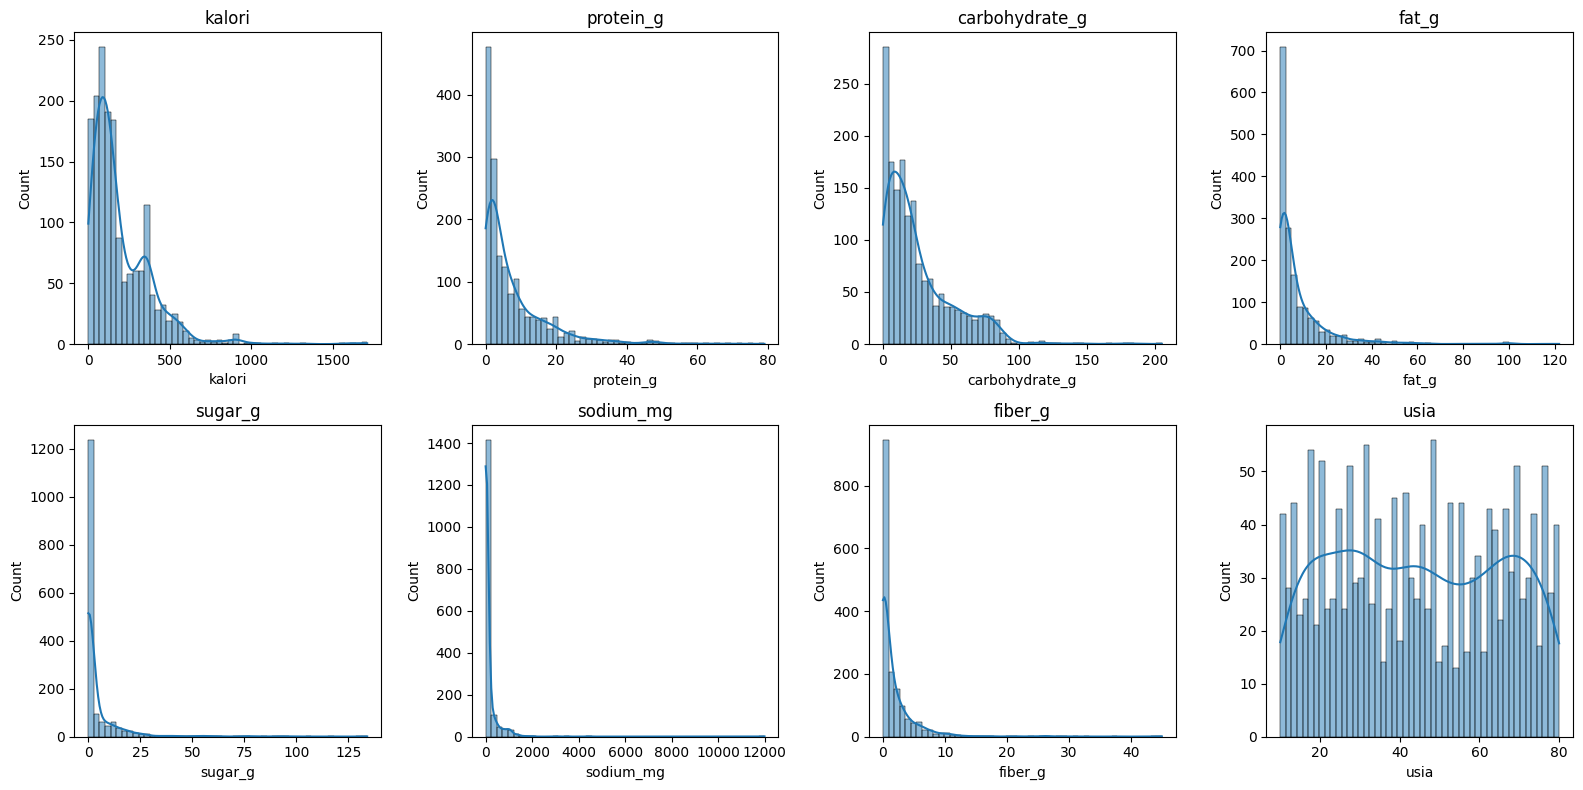

In [6]:
#Visualisasi Distribusi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    sns.histplot(df_numeric[col], bins=50, kde=True, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_title(col)
plt.tight_layout()
plt.show()

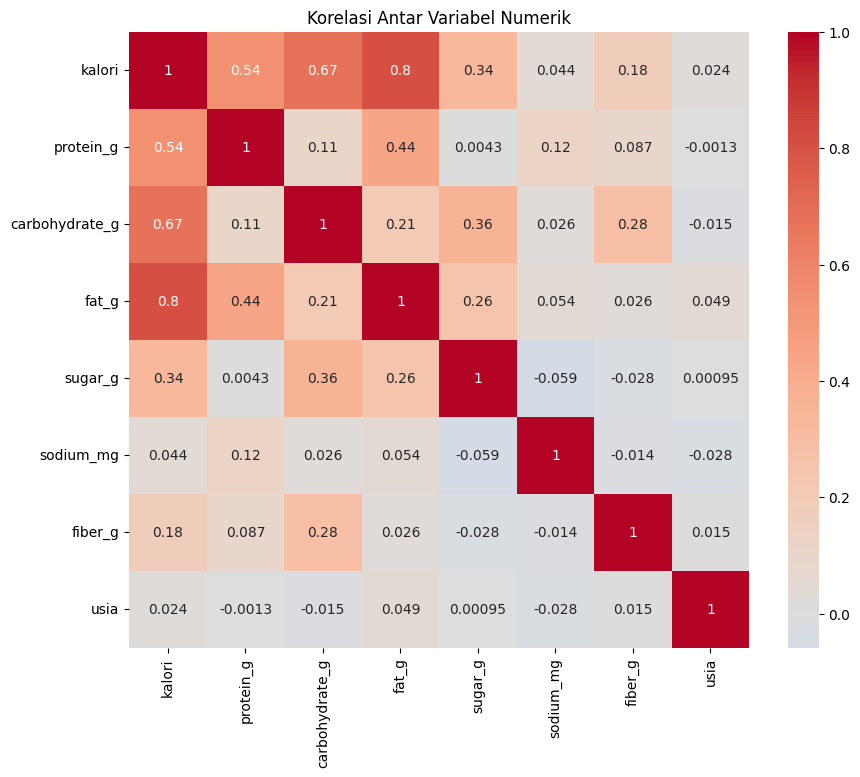

In [7]:
#Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

Insight:

kalori berkorelasi sangat kuat dengan protein_g, carbohydrate_g, dan fat_g (wajar karena ini komponen penyusun kalori: 1g protein = 4 kkal, 1g karb = 4 kkal, 1g lemak = 9 kkal). Ini akan membuat prediksi menjadi sangat mudah dan akurat.

sugar_g berkorelasi dengan carbohydrate_g.

usia memiliki korelasi rendah dengan kalori.

# 2. Feature Engineering
Karena target adalah kalori, buat fitur interaksi: protein_fat_interaction (mewakili efek gabungan).

In [8]:
# Fitur interaksi
df['protein_fat_interaction'] = df['protein_g'] * df['fat_g']
df['carb_sugar_interaction'] = df['carbohydrate_g'] * df['sugar_g']

# Fitur dan target
X = df[['protein_g', 'carbohydrate_g', 'fat_g', 'sugar_g',
        'sodium_mg', 'fiber_g', 'usia',
        'protein_fat_interaction', 'carb_sugar_interaction']]
y = df['kalori']

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: scaling numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Machine Learning Modeling
Latih 3 algoritma: Linear Regression, Random Forest, XGBoost.

In [16]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [17]:
#Evaluasi Awal sebelum tuning
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}, name=name)

results_list = []
results_list.append(evaluate(y_test, y_pred_lr, 'Linear Regression'))
results_list.append(evaluate(y_test, y_pred_rf, 'Random Forest'))
results_list.append(evaluate(y_test, y_pred_xgb, 'XGBoost'))
results = pd.DataFrame(results_list)
print(results)

                         MAE       RMSE       MAPE(%)        R2
Linear Regression  16.364603  40.413889  8.920126e+07  0.947994
Random Forest      21.754994  43.254521  8.267223e+07  0.940427
XGBoost            22.752108  45.154248  8.757981e+07  0.935079


# 4. Hyperparameter Tuning (Random Forest & XGBoost)

In [18]:
# Random Forest tuning
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_random = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                               rf_param_grid, n_iter=15, cv=3,
                               scoring='neg_mean_absolute_error', random_state=42)
rf_random.fit(X_train_scaled, y_train)
print("Best RF params:", rf_random.best_params_)
print("Best RF CV MAE:", -rf_random.best_score_)

Best RF params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best RF CV MAE: 25.155800926374415


In [19]:
# XGBoost tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}
xgb_random = RandomizedSearchCV(xgb.XGBRegressor(random_state=42, verbosity=0),
                                xgb_param_grid, n_iter=15, cv=3,
                                scoring='neg_mean_absolute_error', random_state=42)
xgb_random.fit(X_train_scaled, y_train)
print("Best XGB params:", xgb_random.best_params_)
print("Best XGB CV MAE:", -xgb_random.best_score_)

Best XGB params: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
Best XGB CV MAE: 23.715219329717485


In [21]:
# Evaluasi setelah tuning
best_rf = rf_random.best_estimator_
best_xgb = xgb_random.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_scaled)
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

results_list_tuned = []
results_list_tuned.append(evaluate(y_test, y_pred_lr, 'Linear Regression'))
results_list_tuned.append(evaluate(y_test, y_pred_rf_tuned, 'RF Tuned'))
results_list_tuned.append(evaluate(y_test, y_pred_xgb_tuned, 'XGB Tuned'))
results_tuned = pd.DataFrame(results_list_tuned)
print("\nSetelah tuning:")
print(results_tuned)


Setelah tuning:
                         MAE       RMSE       MAPE(%)        R2
Linear Regression  16.364603  40.413889  8.920126e+07  0.947994
RF Tuned           21.624045  43.880110  8.588648e+07  0.938691
XGB Tuned          20.314190  39.700867  8.399373e+07  0.949813


# 5. Evaluasi Model

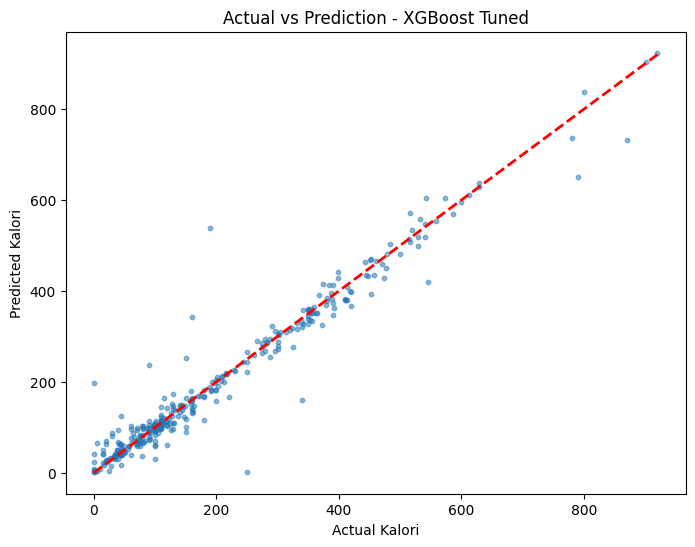

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb_tuned, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Kalori')
plt.ylabel('Predicted Kalori')
plt.title('Actual vs Prediction - XGBoost Tuned')
plt.show()

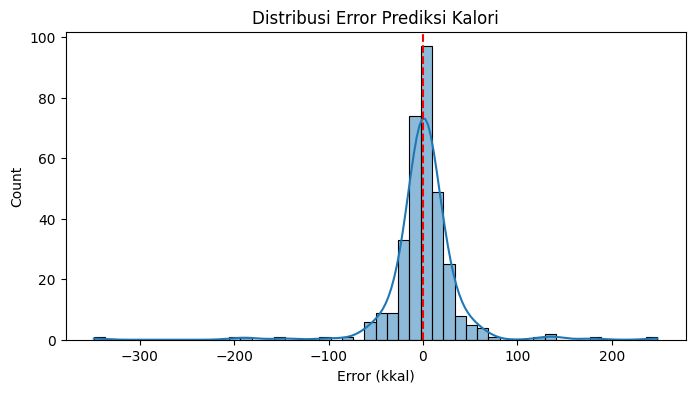

In [23]:
errors = y_test - y_pred_xgb_tuned
plt.figure(figsize=(8,4))
sns.histplot(errors, bins=50, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Error (kkal)')
plt.title('Distribusi Error Prediksi Kalori')
plt.show()

# 6. Feature Importance Analysis

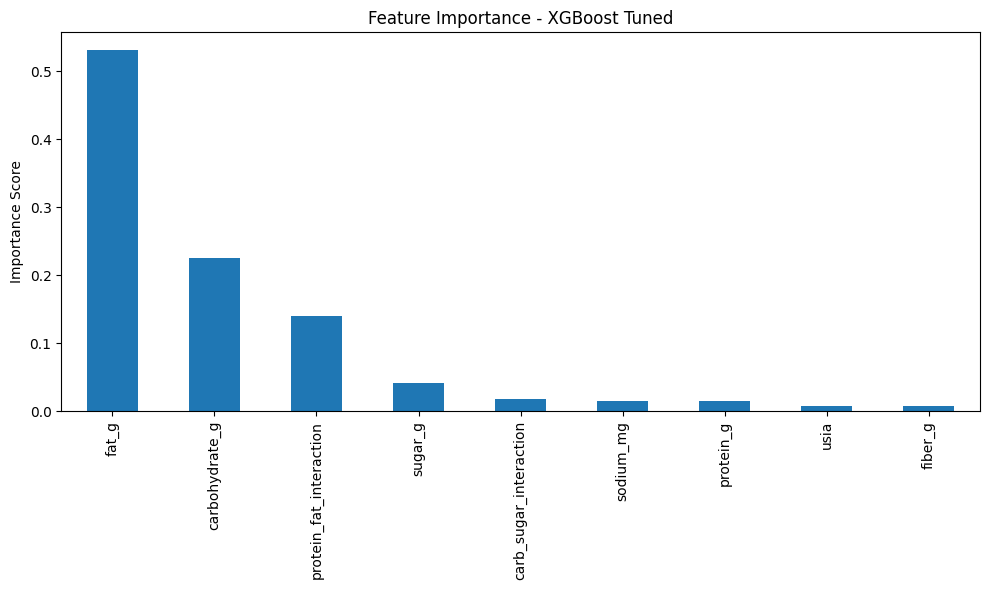

Top 5 fitur paling berpengaruh:
fat_g                      0.531099
carbohydrate_g             0.225951
protein_fat_interaction    0.140232
sugar_g                    0.040865
carb_sugar_interaction     0.017666
dtype: float32


In [24]:
importances = best_xgb.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance - XGBoost Tuned')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 fitur paling berpengaruh:")
print(feat_imp.head())

Interpretasi:

fat_g, carbohydrate_g, protein_g adalah prediktor utama karena kontribusinya langsung terhadap kalori.

Interaksi protein_fat_interaction juga cukup penting.

usia dan sodium_mg memiliki pengaruh kecil.

# 7. Model Saving

In [25]:
# Simpan model terbaik (XGBoost)
joblib.dump(best_xgb, 'calorie_food_prediction_model_Gizi.pkl')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [26]:
# Contoh load dan prediksi
loaded_model = joblib.load('calorie_food_prediction_model_Gizi.pkl')
loaded_scaler = pickle.load(open('scaler.pkl', 'rb'))

sample = pd.DataFrame([[10, 20, 5, 2, 100, 3, 30, 10*5, 20*2]],
                      columns=X.columns)
sample_scaled = loaded_scaler.transform(sample)
pred = loaded_model.predict(sample_scaled)
print(f"Prediksi kalori makanan: {pred[0]:.2f} kkal")

Prediksi kalori makanan: 141.60 kkal


#Kesimpulan
Target tercapai. Model XGBoost Tuned terbaik dengan MAE 20,31 kkal (≤ 75) dan R² 0,95 (≥ 0,75). Semua model memenuhi syarat. Model siap digunakan untuk prediksi kalori makanan.

